In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import os
os.chdir("/home/zongchen/mmd_flow_cubature")
import matplotlib.cm as cm
import matplotlib

import sys
sys.path.append("/home/zongchen/mmd_flow_cubature")
from mmd_flow.kernels import gaussian_kernel
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")

from tqdm import tqdm

plt.rcParams['axes.grid'] = True
plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.labelsize'] = 18
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath, amsfonts}')

# plt.rc('font', family='Arial', size=12)
plt.rc('axes', titlesize=16, labelsize=18, grid=True)
plt.rc('lines', linewidth=2)
plt.rc('legend', fontsize=18, frameon=False)
plt.rc('xtick', labelsize=14, direction='in')
plt.rc('ytick', labelsize=14, direction='in')
plt.rc('figure', figsize=(6, 4), dpi=100)

In [2]:
trajectory = jnp.load("/home/zongchen/mini_mmd/Ys.npy")

from mmd_flow.distributions import Cross
from mmd_flow.kernels import gaussian_kernel

k = 2
w = 0.2
h = 1.0
skip = 1.5
kernel = gaussian_kernel(0.5)
distribution = Cross(kernel=kernel, w=w, h=h, k=k, skip=skip)

rng_key = jax.random.PRNGKey(1)
iid_samples = distribution.sample(20, rng_key)

resolution = 100
h_prime = 0.75
x_lower, x_upper = -h_prime - skip * (k-1), h_prime
y_lower, y_upper = -h_prime, h_prime + skip * (k-1)
x = np.linspace(x_lower, x_upper, resolution)
y = np.linspace(y_lower, y_upper, resolution)
X, Y = np.meshgrid(x, y)

pdf = distribution.pdf(jnp.array([X.flatten(), Y.flatten()]).T)
pdf = pdf.reshape(X.shape)


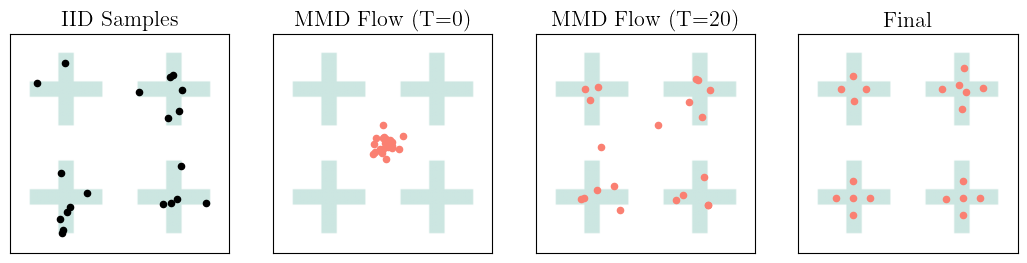

In [5]:
import matplotlib.colors as mcolors
# 204, 230, 225
custom_color = (204/255, 230/255, 225/255)
cmap = mcolors.ListedColormap([custom_color])
cmap.set_bad('white')  # NaN will be white

fig, axs = plt.subplots(1, 4, figsize=(13, 4))
for i in range(4):
    axs[i].imshow(pdf, extent=(x_lower, x_upper, y_lower, y_upper), vmin=0, vmax=1, cmap=cmap)
    axs[i].grid(False)               # Turn off grid
    axs[i].set_xticks([])           # Remove x ticks
    axs[i].set_yticks([])           # Remove y ticks
    axs[i].set_xlabel('')           # Remove x-axis label
    axs[i].set_ylabel('')           # Remove y-axis label

axs[0].scatter(iid_samples[:, 0], iid_samples[:, 1], s=20, c='black', alpha=1.0)
axs[0].set_title("IID Samples")

N = 20
d = 2
Y = jax.random.normal(rng_key, shape=(N, d)) / 10. + jnp.array([[-0.75, 0.75]])
axs[1].scatter(Y[:, 0], Y[:, 1], s=20, c='salmon', alpha=1.0)
axs[1].set_title("MMD Flow (T=0)")

axs[2].scatter(trajectory[2, :, 0], trajectory[2, :, 1], s=20, c='salmon', alpha=1.0)
axs[2].set_title("MMD Flow (T=20)")

axs[3].scatter(trajectory[-1, :, 0], trajectory[-1, :, 1], s=20, c='salmon', alpha=1.0)
axs[3].set_title("Final")
save_path = "/home/zongchen/mini_mmd/plotting/figures/illustration_sampling.pdf"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, bbox_inches='tight')
plt.show()
